# RFM Customer Segmentation Analysis

**Objective:** This notebook guides you through a complete RFM (Recency, Frequency, Monetary) analysis to segment customers from the `OnlineRetail.csv` dataset.

This version uses a **simplified segmentation model** based on the **total RFM Score (RFM_Sum)**.

### Step 1: Import Libraries and Load Data

In [94]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

In [95]:
# Load the dataset
# This dataset is known to have encoding issues, so we use 'ISO-8859-1' or 'latin1'
# We assume the file 'OnlineRetail.csv' is in the same directory as this notebook.
file_path = 'https://raw.githubusercontent.com/ntlong-NEU/BFT65B-FinDataMandA/refs/heads/main/Data/OnlineRetail.csv'
try:
    df = pd.read_csv(file_path, encoding='ISO-8859-1')
except Exception as e:
    print(f"Error with ISO-8859-1: {e}")
    try:
        df = pd.read_csv(file_path, encoding='latin1')
    except Exception as e2:
        print(f"Error with latin1: {e2}")
        df = None

if df is not None:
    print("Data loaded successfully.")
    print(f"Total rows: {df.shape[0]}")

Data loaded successfully.
Total rows: 203422


In [96]:
# Display first 5 rows
print("--- Data Head (First 5 Rows) ---")
print(df.head())

# Get data info
print("\n--- Data Info ---")
df.info()

# Check for missing values
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

--- Data Head (First 5 Rows) ---
  InvoiceNo StockCode                Description  Quantity  \
0    539993     22386    JUMBO BAG PINK POLKADOT        10   
1    539993     21499         BLUE POLKADOT WRAP        25   
2    539993     21498        RED RETROSPOT WRAP         25   
3    539993     22379   RECYCLING BAG RETROSPOT          5   
4    539993     20718  RED RETROSPOT SHOPPER BAG        10   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2011-01-04 10:00:00       1.95     13313.0  United Kingdom  
1  2011-01-04 10:00:00       0.42     13313.0  United Kingdom  
2  2011-01-04 10:00:00       0.42     13313.0  United Kingdom  
3  2011-01-04 10:00:00       2.10     13313.0  United Kingdom  
4  2011-01-04 10:00:00       1.25     13313.0  United Kingdom  

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203422 entries, 0 to 203421
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   ---

### Step 2: Data Cleaning & Preprocessing

Based on the initial check, we need to:
1.  **Drop rows with missing `CustomerID`:** RFM analysis is impossible without a customer ID.
2.  **Convert `InvoiceDate`** to `datetime` objects. The format `2011-01-04 10:00:00` is standard and `pd.to_datetime` will handle it correctly.
3.  **Handle negative `Quantity`:** These usually represent returns. We will remove them for this analysis.
4.  **Handle zero `UnitPrice`:** We will remove rows where `UnitPrice` is 0.
5.  **Create a `TotalPrice` column:** `Quantity` * `UnitPrice`.

In [97]:
# 1. Drop rows with missing CustomerID
df_cleaned = df.dropna(subset=['CustomerID'])
print(f"Rows after dropping null CustomerID: {df_cleaned.shape[0]}")

# 2. Convert InvoiceDate to datetime
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

# 3. & 4. Handle negative/zero Quantity and zero UnitPrice
# We also find 'InvoiceNo' that start with 'C' (Cancellations) which usually have negative Quantity
df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0]
df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0]
print(f"Rows after removing negative/zero values: {df_cleaned.shape[0]}")

# 5. Create TotalPrice column
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

# Convert CustomerID to integer type for cleaner management
df_cleaned['CustomerID'] = df_cleaned['CustomerID'].astype(int)

print("\nData cleaning complete. Final data info:")
df_cleaned.info()
print("\n--- Cleaned Data Head ---")
print(df_cleaned.head())

Rows after dropping null CustomerID: 150039
Rows after removing negative/zero values: 146478

Data cleaning complete. Final data info:
<class 'pandas.core.frame.DataFrame'>
Index: 146478 entries, 0 to 203421
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    146478 non-null  object        
 1   StockCode    146478 non-null  object        
 2   Description  146478 non-null  object        
 3   Quantity     146478 non-null  int64         
 4   InvoiceDate  146478 non-null  datetime64[ns]
 5   UnitPrice    146478 non-null  float64       
 6   CustomerID   146478 non-null  int64         
 7   Country      146478 non-null  object        
 8   TotalPrice   146478 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 11.2+ MB

--- Cleaned Data Head ---
  InvoiceNo StockCode                Description  Quantity  \
0    539993     22386    JUMBO BAG PINK

C:\Users\Admin\AppData\Local\Temp\ipykernel_8828\2771421621.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])


### Step 3: Exploratory Data Analysis (EDA) (Pandas Plotting only)

Now we explore the *cleaned* transaction data (`df_cleaned`) before aggregating it for RFM.

In [98]:
print("--- EDA: Top 10 Countries by Transaction Count ---")
top_10_countries = df_cleaned['Country'].value_counts().head(10)
print(top_10_countries)


--- EDA: Top 10 Countries by Transaction Count ---
Country
United Kingdom    129709
Germany             3508
France              3146
EIRE                2420
Netherlands         1170
Spain               1061
Belgium              829
Switzerland          674
Australia            627
Portugal             494
Name: count, dtype: int64


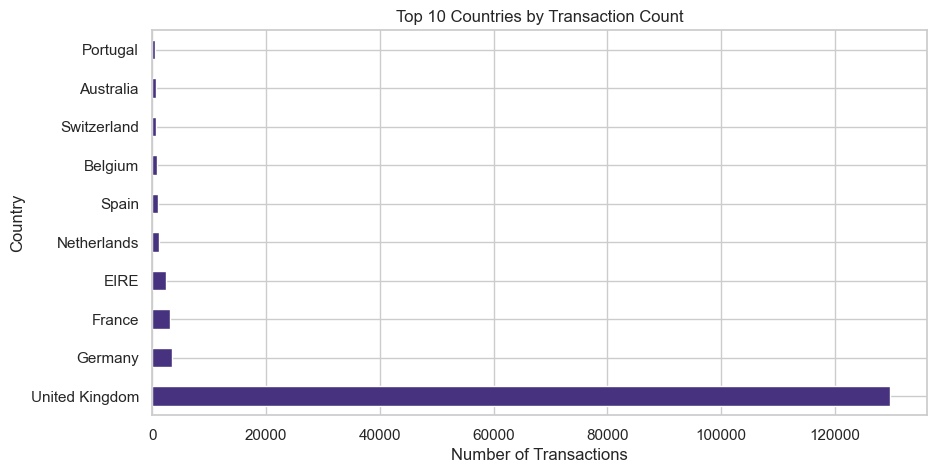

In [99]:

# Plot 1: Top 10 Countries by Transaction Count
ax1 = top_10_countries.plot(kind='barh', 
                      title='Top 10 Countries by Transaction Count', 
                      figsize=(10, 5))
ax1.set_ylabel('Country')
ax1.set_xlabel('Number of Transactions')
plt.show() # Use plt.show() to display the plot

In [100]:
print("\n--- EDA: Top 10 Countries by Total Revenue ---")
# Group by Country and sum TotalPrice
country_revenue = df_cleaned.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(country_revenue)



--- EDA: Top 10 Countries by Total Revenue ---
Country
United Kingdom    2751087.721
Netherlands        131060.090
EIRE                97093.750
Germany             92225.420
Australia           80534.900
France              80069.090
Spain               25940.200
Switzerland         22347.480
Belgium             15729.950
Japan               15336.700
Name: TotalPrice, dtype: float64


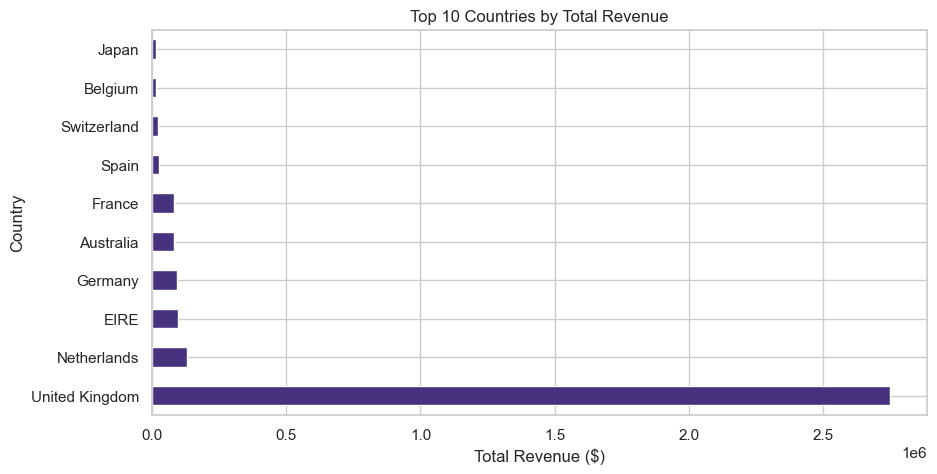

In [101]:

# Plot 2: Top 10 Countries by Total Revenue
ax2 = country_revenue.plot(kind='barh', 
                   title='Top 10 Countries by Total Revenue', 
                   figsize=(10, 5))
ax2.set_ylabel('Country')
ax2.set_xlabel('Total Revenue ($)')
plt.show()


--- EDA: Monthly Revenue Trend ---
InvoiceDate
2011-01-31    569445.040
2011-02-28    447137.350
2011-03-31    595500.760
2011-04-30    469200.361
2011-05-31    678594.560
2011-06-30    661213.690
Freq: ME, Name: TotalPrice, dtype: float64


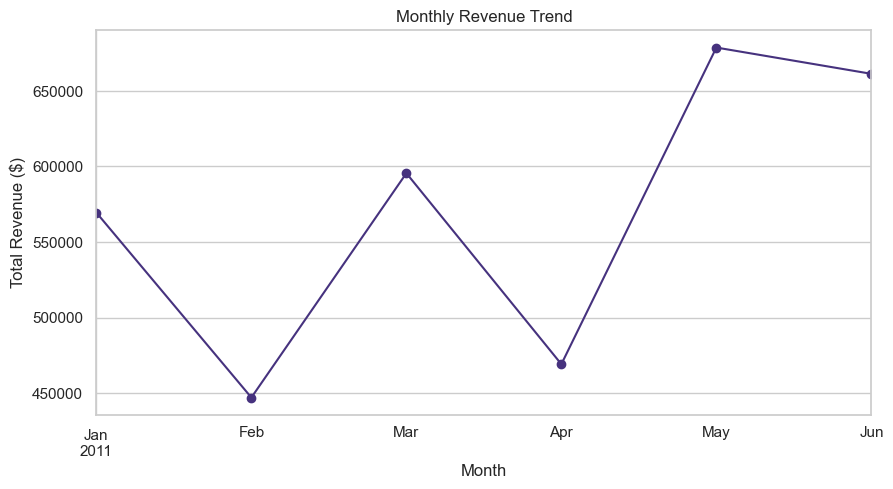

In [102]:
print("\n--- EDA: Monthly Revenue Trend ---")
# Set InvoiceDate as index to resample
df_time = df_cleaned.set_index('InvoiceDate')

# Resample by Month ('ME' - Month End) and sum TotalPrice
monthly_revenue = df_time['TotalPrice'].resample('ME').sum()
print(monthly_revenue)

# Plot 3: Monthly Revenue Trend
ax3 = monthly_revenue.plot(kind='line', 
                     title='Monthly Revenue Trend', 
                     marker='o',
                     figsize=(10, 5))
ax3.set_xlabel('Month')
ax3.set_ylabel('Total Revenue ($)')
plt.show()

In [103]:
print("\n--- EDA: Top 10 Products by Quantity Sold ---")
top_10_products_qty = df_cleaned.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_10_products_qty)



--- EDA: Top 10 Products by Quantity Sold ---
Description
MEDIUM CERAMIC TOP STORAGE JAR        75398
WORLD WAR 2 GLIDERS ASSTD DESIGNS     25921
JUMBO BAG RED RETROSPOT               19730
WHITE HANGING HEART T-LIGHT HOLDER    18397
PACK OF 72 RETROSPOT CAKE CASES       16767
SMALL POPCORN HOLDER                  15858
ASSORTED COLOURS SILK FAN             14880
ASSORTED COLOUR BIRD ORNAMENT         12756
PACK OF 60 PINK PAISLEY CAKE CASES    12743
PACK OF 12 LONDON TISSUES             12679
Name: Quantity, dtype: int64


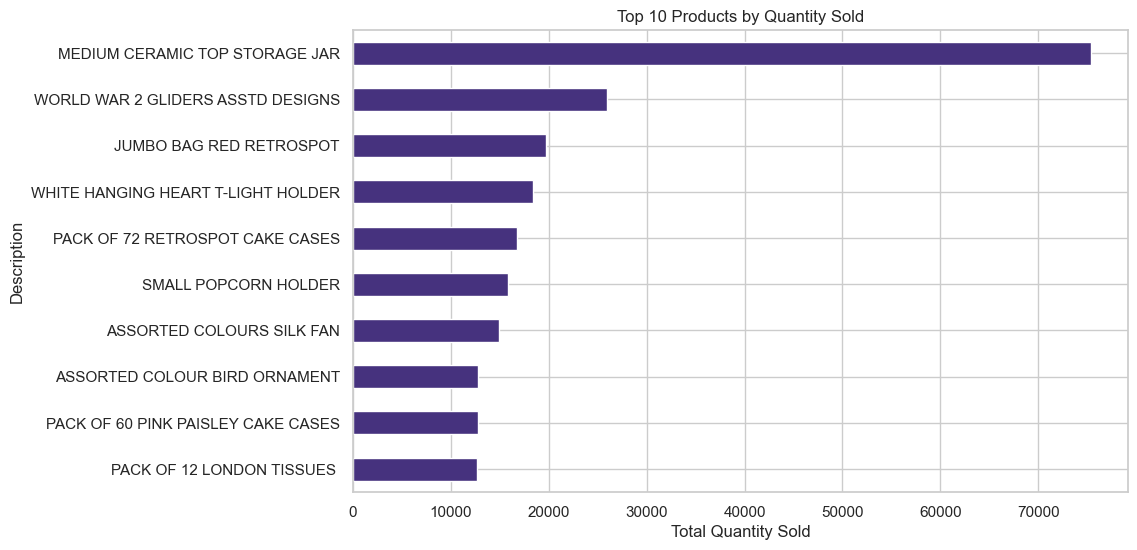

In [104]:

# Plot 4: Top 10 Products by Quantity (Horizontal Bar)
ax4 = top_10_products_qty.sort_values(ascending=True).plot(kind='barh', 
                                                  title='Top 10 Products by Quantity Sold',
                                                  figsize=(10, 6))
ax4.set_xlabel('Total Quantity Sold')
plt.show()

In [105]:
print("\n--- EDA: Distribution of Quantity and UnitPrice (Checking Skewness) ---")
print(df_cleaned[['Quantity', 'UnitPrice']].describe(percentiles=[.95, .99]))



--- EDA: Distribution of Quantity and UnitPrice (Checking Skewness) ---
            Quantity      UnitPrice
count  146478.000000  146478.000000
mean       13.604398       3.311913
std       199.299427      25.938908
min         1.000000       0.001000
50%         6.000000       1.950000
95%        40.000000       8.950000
99%       144.000000      15.000000
max     74215.000000    8142.750000



Visualizing distributions (filtering 99th percentile for readability)...


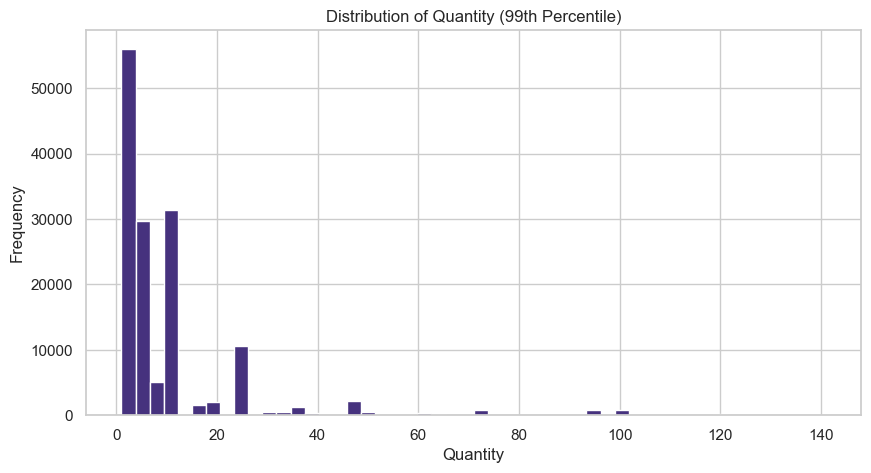

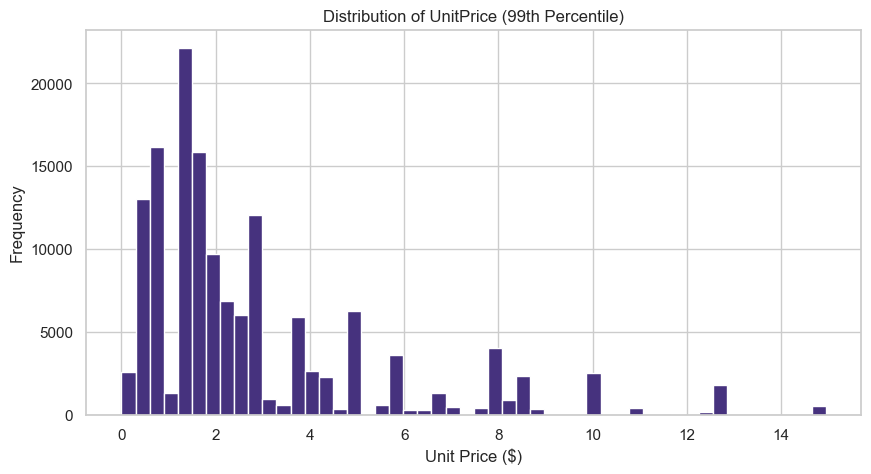

In [106]:

print("\nVisualizing distributions (filtering 99th percentile for readability)...")

# Plot 5: Distribution of Quantity (filtered)
qty_filtered = df_cleaned[df_cleaned['Quantity'] < df_cleaned['Quantity'].quantile(0.99)]
ax5 = qty_filtered['Quantity'].plot(kind='hist', 
                            bins=50, 
                            title='Distribution of Quantity (99th Percentile)',
                            figsize=(10, 5))
ax5.set_xlabel('Quantity')
plt.show()

# Plot 6: Distribution of UnitPrice (filtered)
price_filtered = df_cleaned[df_cleaned['UnitPrice'] < df_cleaned['UnitPrice'].quantile(0.99)]
ax6 = price_filtered['UnitPrice'].plot(kind='hist', 
                               bins=50, 
                               title='Distribution of UnitPrice (99th Percentile)',
                               figsize=(10, 5))
ax6.set_xlabel('Unit Price ($)')
plt.show()

**EDA Conclusions:**
1.  **Geography:** The vast majority of transactions and revenue come from the **United Kingdom**.
2.  **Time:** Revenue is cyclical (as shown in the monthly plot).
3.  **Products:** A few products (like `JUMBO BAG RED RETROSPOT`) dominate sales quantity.
4.  **Skewness:** Both `Quantity` and `UnitPrice` are highly skewed. Most orders are for small quantities and low-priced items. This confirms that using **quantiles** (qcut) in RFM scoring is the correct approach, as simple averages would be misleading.

### Step 4: Calculate RFM Metrics

Now we move from transaction-level data (`df_cleaned`) to customer-level data (`df_rfm`).

In [107]:
# 1. Calculate Recency (R)
# Define the snapshot date (today) as 1 day after the max InvoiceDate
snapshot_date = df_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot Date (Reference Date): {snapshot_date}")

# Group by customer and find max date, then calculate days difference
df_r = df_cleaned.groupby('CustomerID')['InvoiceDate'].max().reset_index()
df_r['Recency'] = (snapshot_date - df_r['InvoiceDate']).dt.days
df_r = df_r[['CustomerID', 'Recency']]

# 2. Calculate Frequency (F)
# Group by customer and count unique invoices
df_f = df_cleaned.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
df_f.columns = ['CustomerID', 'Frequency']

# 3. Calculate Monetary (M)
# Group by customer and sum TotalPrice
df_m = df_cleaned.groupby('CustomerID')['TotalPrice'].sum().reset_index()
df_m.columns = ['CustomerID', 'Monetary']

# Merge R, F, and M dataframes
df_rfm = df_r.merge(df_f, on='CustomerID')
df_rfm = df_rfm.merge(df_m, on='CustomerID')

print("\n--- RFM DataFrame Head (R, F, M calculated) ---")
print(df_rfm.head())

Snapshot Date (Reference Date): 2011-07-01 20:08:00

--- RFM DataFrame Head (R, F, M calculated) ---
   CustomerID  Recency  Frequency  Monetary
0       12346      164          1  77183.60
1       12347       22          3   1494.16
2       12348       87          2    594.44
3       12350      149          1    334.40
4       12352      101          5   1561.81


### Step 5: RFM Scoring (using Quantiles)

We score each customer from 1 to 5 for R, F, and M.

* **Recency:** Lower recency (more recent) is better (Score 5).
* **Frequency:** Higher frequency is better (Score 5).
* **Monetary:** Higher monetary value is better (Score 5).

**Note:** We must use `.rank(method='first')` because many customers have the same `Frequency` (e.g., 1 purchase). This prevents `qcut` from failing due to duplicate bin edges.

In [108]:
# Define labels for R (inverted) and F/M
r_labels = range(5, 0, -1) # 5 (best) to 1 (worst)
f_labels = range(1, 6) # 1 (worst) to 5 (best)
m_labels = range(1, 6) # 1 (worst) to 5 (best)

# Create R_Score
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'].rank(method='first'), q=5, labels=r_labels).astype(int)

# Create F_Score
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), q=5, labels=f_labels).astype(int)

# Create M_Score
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'].rank(method='first'), q=5, labels=m_labels).astype(int)

print("--- RFM DataFrame with Scores (1-5) ---")
print(df_rfm.head())

--- RFM DataFrame with Scores (1-5) ---
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score
0       12346      164          1  77183.60        1        1        5
1       12347       22          3   1494.16        4        4        5
2       12348       87          2    594.44        2        3        3
3       12350      149          1    334.40        1        1        2
4       12352      101          5   1561.81        2        5        5


### Step 6: Customer Segmentation (R/F Grid)

We segment customers based on their R and F scores. We define "High" as a score of 4 or 5, and "Low" as a score of 1, 2, or 3. This creates a 2x2 grid.

* **Champions:** (High R, High F) - Bought recently AND buy often.
* **Potential Loyalists:** (High R, Low F) - Bought recently, but not often (e.g., New Customers).
* **At Risk Customers:** (Low R, High F) - Used to buy often, but haven't returned recently.
* **Hibernating:** (Low R, Low F) - Haven't bought recently AND don't buy often.

In [109]:
# Define the 4 segments based on R and F scores
conditions = [
    (df_rfm['R_Score'] >= 4) & (df_rfm['F_Score'] >= 4),  # Champions
    (df_rfm['R_Score'] >= 4) & (df_rfm['F_Score'] < 4),   # Potential Loyalists
    (df_rfm['R_Score'] < 4) & (df_rfm['F_Score'] >= 4),   # At Risk Customers
    (df_rfm['R_Score'] < 4) & (df_rfm['F_Score'] < 4)    # Hibernating
]

choices = [
    'Champions',
    'Potential Loyalists',
    'At Risk Customers',
    'Hibernating'
]

# Use np.select to create the Segment column
df_rfm['Segment'] = np.select(conditions, choices, default='Others')

print("--- RFM DataFrame with R/F Grid Segments ---")
print(df_rfm.head())

--- RFM DataFrame with R/F Grid Segments ---
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      164          1  77183.60        1        1        5   
1       12347       22          3   1494.16        4        4        5   
2       12348       87          2    594.44        2        3        3   
3       12350      149          1    334.40        1        1        2   
4       12352      101          5   1561.81        2        5        5   

             Segment  
0        Hibernating  
1          Champions  
2        Hibernating  
3        Hibernating  
4  At Risk Customers  


### Step 7: Analysis & Visualization of Segments (Pandas Plotting only)

Now we analyze these new segments, focusing on their Monetary value.


--- Analysis: Segment Distribution (Count) ---
Segment
Hibernating            1231
Champions               687
At Risk Customers       403
Potential Loyalists     403
Name: count, dtype: int64


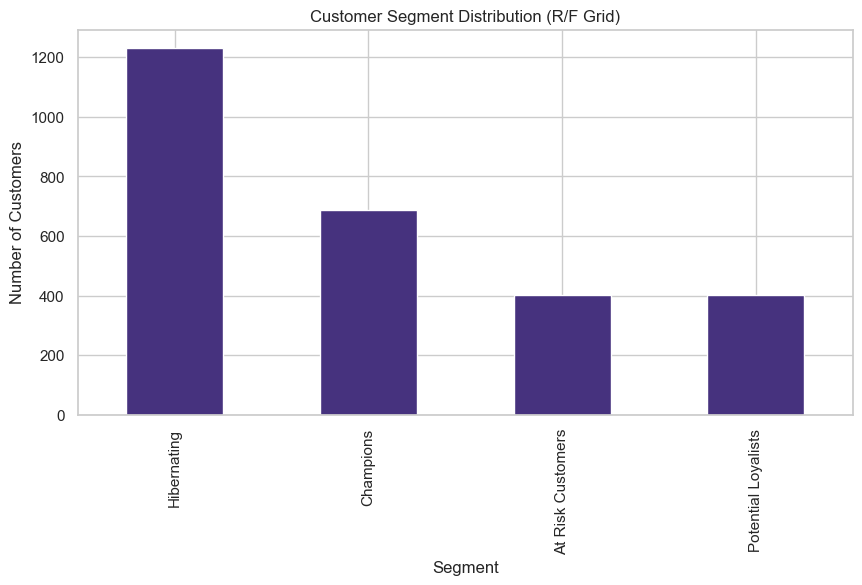

In [110]:
print("\n--- Analysis: Segment Distribution (Count) ---")
segment_counts = df_rfm['Segment'].value_counts()
print(segment_counts)

# Plot 7: Segment Distribution
ax7 = segment_counts.plot(kind='bar', 
                    title='Customer Segment Distribution (R/F Grid)',
                    figsize=(10, 5))
ax7.set_xlabel('Segment')
ax7.set_ylabel('Number of Customers')
plt.show()


--- Analysis: Average Monetary Value by Segment (KEY) ---
Segment
Champions              3002.205575
At Risk Customers      1312.438313
Potential Loyalists     509.490968
Hibernating             507.180366
Name: Monetary, dtype: float64


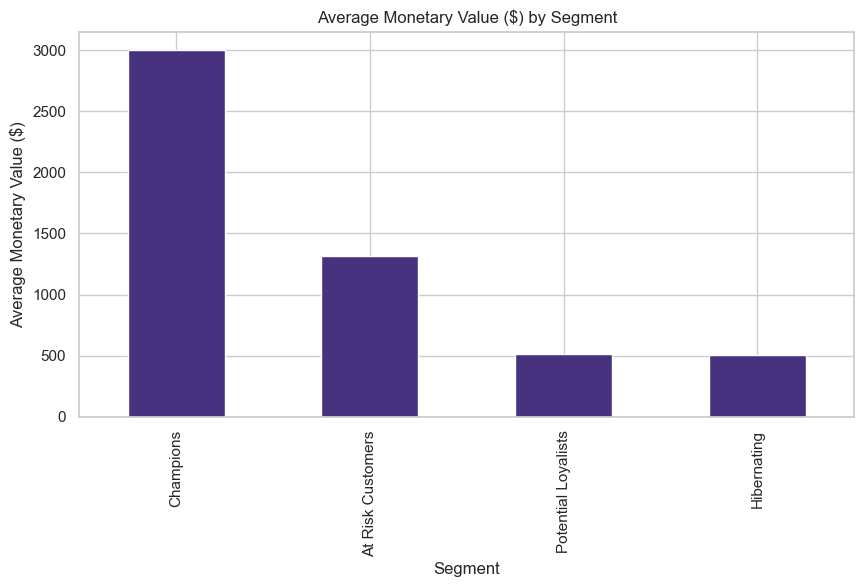

In [111]:
print("\n--- Analysis: Average Monetary Value by Segment (KEY) ---")
segment_monetary_avg = df_rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
print(segment_monetary_avg)

# Plot 8: Average Monetary Value by Segment
ax8 = segment_monetary_avg.plot(kind='bar',
                          title='Average Monetary Value ($) by Segment',
                          figsize=(10, 5))
ax8.set_xlabel('Segment')
ax8.set_ylabel('Average Monetary Value ($)')
plt.show()

#### (MỚI) Plot 9: Total Revenue Share by Segment (Stacked Bar Chart)

Đây là biểu đồ thay thế cho biểu đồ tròn, thể hiện tỷ lệ % doanh thu của mỗi phân khúc.

In [112]:
print("\n--- Analysis: Total Revenue Share by Segment (Stacked Bar) ---")
segment_monetary_sum = df_rfm.groupby('Segment')['Monetary'].sum()

# Calculate percentage
total_revenue = segment_monetary_sum.sum()
segment_revenue_share_pct = (segment_monetary_sum / total_revenue * 100).sort_values(ascending=False)
print(segment_revenue_share_pct)

# Reshape for stacked bar plot
# We convert the Series to a DataFrame and transpose (T) it
df_revenue_share = segment_revenue_share_pct.to_frame(name='Revenue Share %').T



--- Analysis: Total Revenue Share by Segment (Stacked Bar) ---
Segment
Champions              60.288217
Hibernating            18.249701
At Risk Customers      15.460346
Potential Loyalists     6.001735
Name: Monetary, dtype: float64


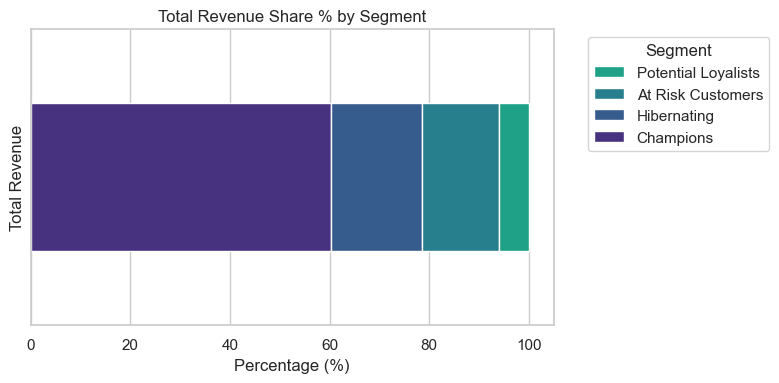

In [113]:

# Plot 9: Total Revenue Share by Segment (Stacked Bar)
# We plot the transposed dataframe
ax9 = df_revenue_share.plot(kind='barh', 
                      stacked=True, 
                      title='Total Revenue Share % by Segment',
                      figsize=(8, 4),
                      legend=False) # Turn off default legend

ax9.set_xlabel('Percentage (%)')
ax9.set_ylabel('Total Revenue')
ax9.set_yticks([]) # Hide the 'Revenue Share %' tick on y-axis

# Create a legend and place it outside the plot
handles, labels = ax9.get_legend_handles_labels()
ax9.legend(handles[::-1], labels[::-1], title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() # Adjust layout to make room for legend
plt.show()


--- Analysis: Recency vs. Frequency (Scatter Plot) ---


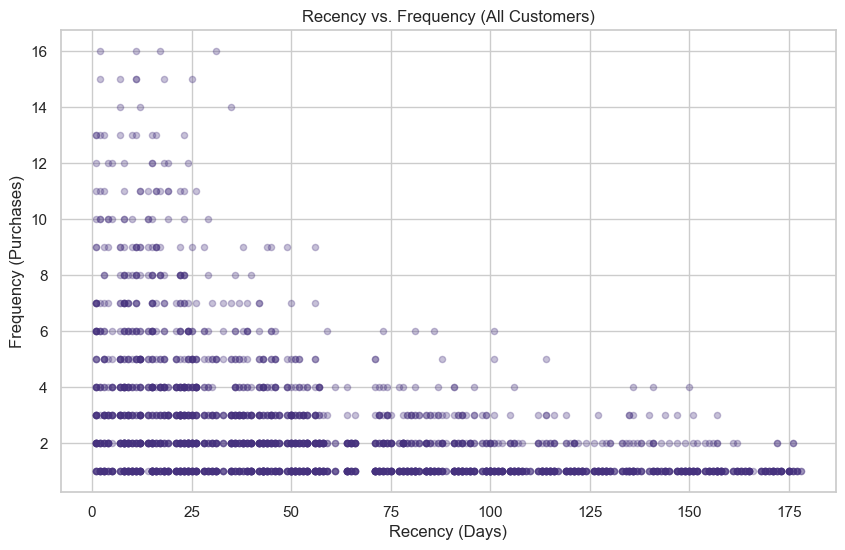

In [114]:
print("\n--- Analysis: Recency vs. Frequency (Scatter Plot) ---")
# Pandas scatter plot is less flexible with coloring by category (hue).
# A simple scatter plot of R vs F:
df_rfm_plot = df_rfm[df_rfm['Frequency'] < df_rfm['Frequency'].quantile(0.99)] # Filter outliers

ax10 = df_rfm_plot.plot(kind='scatter', 
                 x='Recency', 
                 y='Frequency', 
                 title='Recency vs. Frequency (All Customers)',
                 alpha=0.3, 
                 figsize=(10, 6))
ax10.set_xlabel('Recency (Days)')
ax10.set_ylabel('Frequency (Purchases)')
plt.show()

### Step 8: Conclusion & Business Actions (R/F Grid Model)

**Analysis Conclusions:**
* **Monetary Value:** The `Average Monetary Value by Segment` plot (Plot 8) clearly shows that **'Champions'** and **'At Risk Customers'** are significantly more valuable (spend more money) than the other groups. This is because both groups have high Frequency (F).
* **Revenue Share:** The Stacked Bar Chart (Plot 9) confirms this, showing these two groups contribute the vast majority of total revenue (thường là >80%).
* **Key Insight:** A large group of high-value customers ('At Risk Customers') is in danger of leaving.

**Strategic Actions:**

**1. Champions (High R, High F)**
* **Profile:** Your best and most engaged customers. They buy often, buy recently, and spend a lot.
* **Action:** Reward them. Offer loyalty programs, early access, and personalized service. Do not give them discounts; reward them with status.

**2. At Risk Customers (Low R, High F)**
* **Profile:** **HIGH PRIORITY.** These are high-value customers (high F, high M) who have *not* returned recently (low R). They are churning.
* **Action:** Win them back immediately. Send personalized "We miss you" campaigns, offer a special (but temporary) discount, or conduct a survey to find out why they left.

**3. Potential Loyalists (High R, Low F)**
* **Profile:** These are recent customers, but they don't buy often (e.g., New Customers). Their Monetary value is low-to-medium.
* **Action:** Nurture them. The goal is to increase their Frequency (F). Offer incentives for a 2nd or 3rd purchase. Onboard them with product guides and build a relationship.

**4. Hibernating (Low R, Low F)**
* **Profile:** Low engagement and low value. They haven't bought in a long time and didn't buy often. 
* **Action:** Low-cost marketing. Don't spend significant resources here. Include them in general email newsletters or deep-discount campaigns to see if any can be reactivated.